## 1. What this notebook computes

The field equation of dirac16complex (and of dirac16complex00) contains the term
$\gamma^\mu\Omega_\mu\Psi$, where $\Omega_\mu$ is the canonical spin connection. In
the diagonal frame of the author's metric this term is $3H\gamma^{(8)}\Psi$. This
notebook computes everything from the definitions, exactly, with sympy, and shows
what that value means and what it does not mean. It

- builds the author's metric from the diagonal vielbein, its Christoffel symbols
  (25 independent nonzero ones) and the canonical spin connection (12 independent
  nonzero components), and checks the vielbein postulate for all 512 components;
- shows that the connection vanishes only in the formal flat limit $a_4' = 0$,
  $H = 0$ (the core of non-triviality) and that the term $3H\gamma^{(8)}\Psi$ is
  not zero for any field $\Psi \neq 0$;
- shows, direction by direction, which pieces of $\gamma^\mu\Omega_\mu$ cancel (the
  time-direction pieces of the three inflating and the three deflating
  directions) and which survive (the hidden-direction pieces, $3H\gamma^{(8)}$);
- shows that the term contains no $a_4$, although the curvature does
  ($R^{x_4}{}_{x_4} = 6(a_4')^2$): the deflation of the extra times is invisible
  in this term;
- repeats everything in a second, equally valid frame, boosted in the
  $(x_4, x_8)$ plane, finds $\gamma'^\mu\Omega'_\mu = \frac{6H - \beta}{2}
  (\cosh b\,\gamma^{(8)} - \sinh b\,\gamma^{(4)})$, and so a frame in which the
  term is identically ZERO;
- shows that the spin connection itself is not zero in that frame (nor in any
  other): its curvature is the Riemann tensor, which is not zero;
- shows that the spin connection enters the energy-momentum tensor.

Every exact statement reproduces a check of a Revision record. Five teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 08c (The spin-connection term depends on the frame) is the file
`Revision/textbook/notebooks/08c_frame_dependence.ipynb` of the repository Dirac_claude.
From the author's metric and gamma matrices it computes exactly (sympy) the Christoffel
symbols, the canonical spin connection of the diagonal frame and of a frame boosted in
the (x4, x8) plane, and the term gamma^mu Omega_mu of the field equation; it shows that
the connection vanishes only in the formal flat limit, which pieces cancel and which
survive (3 H gamma^(x8) in the diagonal frame), that the term contains no a4 although the
a4 sector is curved, that it vanishes identically in the frame boosted with rapidity 6 H
x4 + b0, that the spin connection itself vanishes in no frame (its curvature is the
Riemann tensor), and that it enters the energy-momentum tensor; it draws five teaching
plots. It needs a computer with Windows 11, macOS or Linux, an internet connection for
the installation, the program Git, and Python 3.12 or newer (the notebooks were built
with Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy
and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 08c_frame_dependence.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 2 minutes on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 08c_frame_dependence.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
08c_frame_dependence.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/08c.captions.json`
- `Revision/textbook/figures/08c_1_cancel_and_survive.png`
- `Revision/textbook/figures/08c_2_pieces_along_history.png`
- `Revision/textbook/figures/08c_3_boost_size.png`
- `Revision/textbook/figures/08c_4_heat_maps.png`
- `Revision/textbook/figures/08c_5_curvature_maps.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 08c_5_curvature_maps.png exists
    ALL 32 CHECKS PASSED (notebook 08c)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/08c_frame_dependence.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- A cell of sections 7, 11 or 12 runs for more than a minute: these cells simplify
  hundreds of exact expressions with sympy; on a slow computer each can take a few
  minutes. Wait until the star in the brackets to the left of the cell turns into a
  number.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 08c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 08c (The spin-connection term depends on the frame) is the file
# Revision/textbook/notebooks/08c_frame_dependence.ipynb of the repository Dirac_claude.
# From the author's metric and gamma matrices it computes exactly (sympy) the Christoffel
# symbols, the canonical spin connection of the diagonal frame and of a frame boosted in
# the (x4, x8) plane, and the term gamma^mu Omega_mu of the field equation; it shows that
# the connection vanishes only in the formal flat limit, which pieces cancel and which
# survive (3 H gamma^(x8) in the diagonal frame), that the term contains no a4 although
# the a4 sector is curved, that it vanishes identically in the frame boosted with
# rapidity 6 H x4 + b0, that the spin connection itself vanishes in no frame (its
# curvature is the Riemann tensor), and that it enters the energy-momentum tensor; it
# draws five teaching plots. It needs a computer with Windows 11, macOS or Linux, an
# internet connection for the installation, the program Git, and Python 3.12 or newer
# (the notebooks were built with Python 3.14.5) with these packages at exactly these
# versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 08c_frame_dependence.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 2
# minutes on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 08c_frame_dependence.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 08c_frame_dependence.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/08c.captions.json
# - Revision/textbook/figures/08c_1_cancel_and_survive.png
# - Revision/textbook/figures/08c_2_pieces_along_history.png
# - Revision/textbook/figures/08c_3_boost_size.png
# - Revision/textbook/figures/08c_4_heat_maps.png
# - Revision/textbook/figures/08c_5_curvature_maps.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 08c_5_curvature_maps.png exists
#     ALL 32 CHECKS PASSED (notebook 08c)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/08c_frame_dependence.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - A cell of sections 7, 11 or 12 runs for more than a minute: these cells simplify
#   hundreds of exact expressions with sympy; on a slow computer each can take a few
#   minutes. Wait until the star in the brackets to the left of the cell turns into a
#   number.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "08c"  # this notebook: chapter 08, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 08c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** (the author's names): $x_1, x_2, x_3$ ordinary space (inflating);
  $x_4$ the time; $x_5, x_6, x_7$ the three extra times (time-like, DEFLATING:
  their scale factor is $e^{-a_4}\sin^{1/6}z$); $x_8$ the hidden direction,
  $z = 6Hx_8$ between $0$ and $\pi/2$. $a_4(x_4)$ is any function of the time.
- **Metric** $g_{\mu\nu}$: the table of numbers that turns coordinate steps into
  lengths, $ds^2 = \sum g_{\mu\nu}dx_\mu dx_\nu$. The author's metric is diagonal:
  $g = \mathrm{diag}(e^{2a_4}\sin^{1/3}z\ (3\times), -1, -e^{-2a_4}\sin^{1/3}z\
  (3\times), \cot^2 z)$.
- **Frame (vielbein)** $e^a{}_\mu$: eight vectors, one per direction $a$, that are
  orthonormal for the metric: $\sum_{a} \eta_{aa}e^a{}_\mu e^a{}_\nu = g_{\mu\nu}$
  with $\eta = \mathrm{diag}(+,+,+,-,-,-,-,+)$. The *diagonal frame* has
  $e^a{}_\mu = f_a\delta^a_\mu$ with $f_a = \sqrt{|g_{aa}|}$. Its inverse is
  $E_a{}^\mu$ (written `E[mu, a]` in the code).
- **Christoffel symbols** $\Gamma^\lambda{}_{\mu\nu}$: the numbers that say how the
  coordinate directions turn from point to point; for a diagonal metric
  $\Gamma^\lambda{}_{\mu\nu} = \frac{1}{2g_{\lambda\lambda}}(\partial_\mu
  g_{\lambda\nu} + \partial_\nu g_{\lambda\mu} - \partial_\lambda g_{\mu\nu})$.
- **Canonical spin connection** $\omega_\mu{}^a{}_b = e^a{}_\nu(\partial_\mu
  E_b{}^\nu + \Gamma^\nu{}_{\mu\lambda}E_b{}^\lambda)$: how the frame vectors turn;
  it obeys the *vielbein postulate* $\partial_\mu e^a{}_\nu -
  \Gamma^\lambda{}_{\mu\nu}e^a{}_\lambda + \omega_\mu{}^a{}_b e^b{}_\nu = 0$, and
  $\omega_{\mu ab} = \eta_{aa}\omega_\mu{}^a{}_b$ is antisymmetric in $a, b$.
- **Spinor connection** $\Omega_\mu = \frac12\sum_{a,b}\omega_{\mu ab}S^{ab}$ with
  $S^{ab} = \frac14[\gamma^{(a)}, \gamma^{(b)}]$; $D_\mu\Psi = \partial_\mu\Psi +
  \Omega_\mu\Psi$ and $\gamma^\mu = \sum_a E_a{}^\mu\gamma^{(a)}$.
- **Boost**: a change of frame that mixes a time-like and a space-like frame vector
  with $\cosh b$ and $\sinh b$ ($b$ is the *rapidity*); because $\cosh^2 b -
  \sinh^2 b = 1$ the new vectors are again orthonormal, so the new frame describes
  the SAME metric.
- **Riemann tensor** $R^\rho{}_{\sigma\mu\nu}$ (curvature) and its traces: the Ricci
  tensor $R_{\sigma\nu} = \sum_\rho R^\rho{}_{\sigma\rho\nu}$, its mixed form
  $R^\mu{}_\nu$ (for a diagonal metric $R^a{}_a = R_{aa}/g_{aa}$) and the Ricci
  scalar $R = \sum_a R^a{}_a$. A space is flat exactly when the Riemann tensor
  vanishes.
- **Spinor curvature** $F_{\mu\nu} = \partial_\mu\Omega_\nu - \partial_\nu\Omega_\mu
  + [\Omega_\mu, \Omega_\nu]$, where $[A, B] = AB - BA$ (the *commutator*); the
  record proves $F_{\mu\nu} = \frac14\sum R_{\rho\sigma\mu\nu}\gamma^\rho
  \gamma^\sigma$.
- **Anticommutator** $\{A, B\} = AB + BA$; **trace** of a matrix: the sum of its
  diagonal.

## 4. The physical and mathematical situation

Coupling a spinor field to gravity needs a frame, because the gamma matrices
$\gamma^{(a)}$ belong to the orthonormal frame directions, not to the coordinates.
The frame is not unique: at every point one may turn (rotate or boost) the eight
frame vectors among themselves, and the metric stays the same. The spin connection
changes under such a turn, and so may $\gamma^\mu\Omega_\mu$. A statement is a
property of the field equation only if it holds in every frame (together with the
matching change of the field, $\Psi' = S\Psi$ with a constant-or-varying $16
\times 16$ matrix $S$).

The plan: compute $\gamma^\mu\Omega_\mu$ in the diagonal frame (result
$3H\gamma^{(8)}$, sections 7 to 10), then in the boosted frame
$e'^{(4)} = \cosh b\,e^{(4)} + \sinh b\,e^{(8)}$, $e'^{(8)} = \sinh b\,e^{(4)} +
\cosh b\,e^{(8)}$, other $e'^{(a)} = e^{(a)}$, with rapidity $b = \beta x_4 + b_0$
(section 11), and finally the curvature (section 12), which no frame can remove.

Every symbol is exact: $H > 0$, $\beta$, $b_0$ are letters, and $a_4(x_4)$ is an
unspecified function; so every check holds for EVERY history $a_4$. Only the plots
put numbers in: $H = 1$, $z = \pi/4$, and the canonical history $a_4 = AHx_4$ with
$A = 1$ of the Kohn-Sham record (a prescribed background).

## 5. The metric from the diagonal frame

The next cell first defines two helpers for the checks that reproduce a Revision
record. `record_says(report, name, ...)` opens the report (a JSON file with a list
of checks, each with a name, a verdict and a detail text) and is true when the
check `name` is there with the verdict pass and its detail text contains every
further piece of text given (for example a formula that this notebook computes).
`check_record(condition, title, report, names, ...)` is the helper `check` for such
a result (`names` is one check name or a list of names): it passes only if the
notebook's own computation (`condition`) is right AND the record says the same.
Then the cell reads the gamma matrices, defines the symbols, builds the scale
factors $f_a$ and the metric $g_{aa} = \eta_{aa}f_a^2$, and checks that this is the
author's metric entry by entry (and that the record prints the same eight entries)
and that $\sqrt{|g|} = f_1 f_2 \cdots f_8 = \cos z$. The helper `is_zero` asks sympy
to simplify an expression twice (the second time with its trigonometric simplifier
`fu`) and says whether it is exactly zero.

In [2]:
import numpy as np  # numbers and matrices (for the plots)
import sympy as sp  # exact algebra with symbols

REPORTS = {}  # report file -> {check name: (verdict, detail)}, each read once


def record_says(report_file, check_name, *pieces):
    """True when the Revision report records the check check_name with the verdict
    pass and its detail text contains every given piece of text."""
    if report_file not in REPORTS:  # read the report the first time it is needed
        data = json.loads(repository_file(report_file).read_text(encoding="utf-8"))
        REPORTS[report_file] = {entry["name"]: (entry["verdict"].lower(),
                                                entry["detail"])
                                for entry in data["checks"]}
    verdict, detail = REPORTS[report_file][check_name]
    return verdict == "pass" and all(piece in detail for piece in pieces)


def check_record(condition, title, report_file, check_names, *pieces):
    """check() for a result that reproduces Revision checks (one name or a list of
    names): it passes only if condition is true AND the report records every one
    of them as passed, with every piece of text in the detail of the first one."""
    names = [check_names] if isinstance(check_names, str) else list(check_names)
    on_record = record_says(report_file, names[0], *pieces) and all(
        record_says(report_file, name) for name in names[1:])
    word = "check" if len(names) == 1 else "checks"
    check(condition and on_record, title,
          record=f"{report_file}, {word} " + " and ".join(names))


gammas_record = json.loads(
    repository_file("Revision/algebra/gammas.json").read_text(encoding="utf-8"))
G = [sp.Matrix(rows) for rows in gammas_record["gamma"]]  # gamma^(x1) ... (x8)
ETA = gammas_record["eta"]  # [1, 1, 1, -1, -1, -1, -1, 1]
C = sp.Matrix(gammas_record["C"])  # C = gamma^(x8) gamma^(x1) gamma^(x2) gamma^(x3)

x = sp.symbols("x1:9", real=True)  # the coordinates; x[0] is x1, x[7] is x8
H = sp.Symbol("H", positive=True)
beta, b0 = sp.symbols("beta b0", real=True)  # the boost: rapidity beta x4 + b0
a4 = sp.Function("a4")(x[3])  # the metric function: ANY function of x4
z = 6 * H * x[7]
sixth = sp.sin(z) ** sp.Rational(1, 6)  # sin(z)^(1/6)
f = [sp.exp(a4) * sixth] * 3 + [sp.Integer(1)] + [sp.exp(-a4) * sixth] * 3 \
    + [sp.cot(z)]  # the scale factors f_1, ..., f_8
g = [ETA[a] * f[a] ** 2 for a in range(8)]  # the diagonal entries g_aa
third = sp.sin(z) ** sp.Rational(1, 3)
authors_metric = [sp.exp(2 * a4) * third] * 3 + [-1] \
    + [-sp.exp(-2 * a4) * third] * 3 + [sp.cot(z) ** 2]


def is_zero(expr):
    """True when sympy shows that expr is exactly zero (two simplifications)."""
    expr = sp.sympify(expr)
    if expr == 0:
        return True
    simpler = sp.simplify(expr)
    return simpler == 0 or sp.simplify(sp.fu(simpler)) == 0


# The record prints each entry as sympy writes it, e.g. "g_x8x8 = cot(6*H*x8)**2".
metric_texts = [f"g_x{a + 1}x{a + 1} = {sp.sstr(authors_metric[a])}" for a in range(8)]
say(metric_texts[0])
say(metric_texts[4])
check_record(all(is_zero(g[a] - authors_metric[a]) for a in range(8)),
             "eta_aa f_a^2 is the author's metric (all 8 diagonal entries)",
             "Revision/theory/reports/python-field-theory.json",
             "metric_from_vielbein_equals_SPEC", *metric_texts)
check_record(is_zero(sp.prod(f) - sp.cos(z)), "sqrt|g| = f1 f2 ... f8 = cos z",
             "Revision/theory/reports/python-field-theory.json",
             "sqrt_det_g_equals_cos_z", "cos(6 H x8)")

g_x1x1 = exp(2*a4(x4))*sin(6*H*x8)**(1/3)
g_x5x5 = -exp(-2*a4(x4))*sin(6*H*x8)**(1/3)
PASS eta_aa f_a^2 is the author's metric (all 8 diagonal entries)
     reproduces Revision/theory/reports/python-field-theory.json, check
    metric_from_vielbein_equals_SPEC
PASS sqrt|g| = f1 f2 ... f8 = cos z
     reproduces Revision/theory/reports/python-field-theory.json, check
    sqrt_det_g_equals_cos_z


## 6. The Christoffel symbols

The next cell computes all $8 \times 8 \times 8$ symbols
$\Gamma^\lambda{}_{\mu\nu}$ (stored as `Gam[lam][mu][nu]`) with the formula for a
diagonal metric, counts the independent nonzero ones (those with $\mu \le \nu$,
because $\Gamma^\lambda{}_{\mu\nu} = \Gamma^\lambda{}_{\nu\mu}$), and prints four of
them. sympy writes $a_4'$ as `Derivative(a4(x4), x4)`.

In [3]:
Gam = [[[sp.Integer(0)] * 8 for _ in range(8)] for _ in range(8)]
for lam in range(8):
    for mu in range(8):
        for nu in range(8):
            value = 0  # the bracket of the formula; g is diagonal, so only these
            if lam == nu:  # three cases contribute
                value += sp.diff(g[lam], x[mu])
            if lam == mu:
                value += sp.diff(g[lam], x[nu])
            if mu == nu:
                value -= sp.diff(g[mu], x[lam])
            if value != 0:
                Gam[lam][mu][nu] = sp.simplify(value / (2 * g[lam]))
independent = sum(1 for lam in range(8) for mu in range(8) for nu in range(mu, 8)
                  if Gam[lam][mu][nu] != 0)
report("independent nonzero Christoffel symbols", independent)
for lam, mu, nu in ((0, 0, 3), (4, 3, 4), (0, 0, 7), (7, 7, 7)):
    say(f"Gamma^x{lam + 1}_x{mu + 1} x{nu + 1} = {Gam[lam][mu][nu]}")
check_record(independent == 25, "25 independent nonzero Christoffel symbols",
             "Revision/theory/reports/python-field-theory.json",
             "christoffel_symmetric_metric_compatible",
             f"{independent} independent nonzero symbols")

RESULT independent nonzero Christoffel symbols = 25
Gamma^x1_x1 x4 = Derivative(a4(x4), x4)
Gamma^x5_x4 x5 = -Derivative(a4(x4), x4)
Gamma^x1_x1 x8 = H/tan(6*H*x8)
Gamma^x8_x8 x8 = -12*H/sin(12*H*x8)
PASS 25 independent nonzero Christoffel symbols
     reproduces Revision/theory/reports/python-field-theory.json, check
    christoffel_symmetric_metric_compatible


## 7. The canonical spin connection of the diagonal frame

The function `frame(b)` below builds the frame boosted by the rapidity $b$ (for
$b = 0$ the diagonal frame), its inverse, the mixed connection
$\omega_\mu{}^a{}_c$ (stored as `omega[mu, a, c]`), the spinor connections
$\Omega_\mu$ and the matrices $\gamma^\mu$. `postulate_failures` counts the
components of the vielbein postulate that are NOT zero. The next cell applies them
to the diagonal frame, checks the postulate (512 components) and the antisymmetry,
and prints the 12 independent nonzero components $\omega_{\mu ab}$ ($a < b$).

In [4]:
S_AB = [[(G[a] * G[c] - G[c] * G[a]) / 4 for c in range(8)] for a in range(8)]


def boost(b):
    """The boost by the rapidity b in the frame plane (x4, x8), and its inverse."""
    L, L_inverse = sp.eye(8), sp.eye(8)
    L[3, 3] = L[7, 7] = L_inverse[3, 3] = L_inverse[7, 7] = sp.cosh(b)
    L[3, 7] = L[7, 3] = sp.sinh(b)
    L_inverse[3, 7] = L_inverse[7, 3] = -sp.sinh(b)
    return L, L_inverse


def frame(b):
    """Vielbein e[a, mu], inverse E[mu, a], connection omega[mu, a, c] (mixed),
    Omega_mu and gamma^mu of the diagonal frame boosted by the rapidity b."""
    L, L_inverse = boost(b)
    e = L * sp.diag(*f)
    E = sp.diag(*[1 / value for value in f]) * L_inverse
    omega = {}
    for mu in range(8):
        for a in range(8):
            for c in range(8):
                value = 0  # e^a_nu (d_mu E_c^nu + Gamma^nu_mu,lam E_c^lam)
                for nu in range(8):
                    if e[a, nu] == 0:
                        continue  # skip the terms that are zero anyway
                    term = sp.diff(E[nu, c], x[mu])
                    for lam in range(8):
                        if Gam[nu][mu][lam] != 0 and E[lam, c] != 0:
                            term += Gam[nu][mu][lam] * E[lam, c]
                    value += e[a, nu] * term
                omega[mu, a, c] = sp.simplify(value)
    Omega = []
    for mu in range(8):
        matrix = sp.zeros(16, 16)
        for a in range(8):
            for c in range(a + 1, 8):  # (1/2) sum over all a, c = sum over a < c
                matrix += ETA[a] * omega[mu, a, c] * S_AB[a][c]
        Omega.append(matrix)
    gamma_up = [sum((E[mu, a] * G[a] for a in range(8)), sp.zeros(16, 16))
                for mu in range(8)]
    return {"e": e, "E": E, "omega": omega, "Omega": Omega, "gamma": gamma_up}


def postulate_failures(fr):
    """How many of the 512 components of the vielbein postulate are not zero."""
    failures = 0
    for a in range(8):
        for mu in range(8):
            for nu in range(8):
                value = sp.diff(fr["e"][a, nu], x[mu]) \
                    - sum(Gam[lam][mu][nu] * fr["e"][a, lam] for lam in range(8)) \
                    + sum(fr["omega"][mu, a, c] * fr["e"][c, nu] for c in range(8))
                failures += 0 if is_zero(value) else 1
    return failures


def antisymmetric(fr):
    """omega_mu,ac = eta_aa omega_mu^a_c is antisymmetric in a, c for every mu."""
    return all(is_zero(ETA[a] * fr["omega"][mu, a, c] + ETA[c] * fr["omega"][mu, c, a])
               for mu in range(8) for a in range(8) for c in range(8))


diagonal = frame(sp.Integer(0))
check_record(postulate_failures(diagonal) == 0 and antisymmetric(diagonal),
             "diagonal frame: vielbein postulate (512 components), omega antisymmetric",
             "Revision/theory/reports/python-field-theory.json",
             ["vielbein_postulate", "spin_connection_antisymmetric"],
             "(512 components)")
nonzero = [(mu, a, c) for mu in range(8) for a in range(8) for c in range(a + 1, 8)
           if not is_zero(diagonal["omega"][mu, a, c])]
omega_diagonal = diagonal["omega"]
for mu, a, c in nonzero:
    say(f"omega_x{mu + 1},(x{a + 1})(x{c + 1}) = "
        f"{sp.simplify(ETA[a] * omega_diagonal[mu, a, c])}")
check_record(len(nonzero) == 12, "12 independent nonzero components omega_mu,ab (a < b)",
             "Revision/theory/reports/wolfram-field-theory.json", "omega_components",
             f"exactly {len(nonzero)} independent nonzero omega_mu,ab (a < b)")

PASS diagonal frame: vielbein postulate (512 components), omega antisymmetric
     reproduces Revision/theory/reports/python-field-theory.json, checks
    vielbein_postulate and spin_connection_antisymmetric
omega_x1,(x1)(x4) = exp(a4(x4))*sin(6*H*x8)**(1/6)*Derivative(a4(x4), x4)
omega_x1,(x1)(x8) = H*exp(a4(x4))*sin(6*H*x8)**(1/6)
omega_x2,(x2)(x4) = exp(a4(x4))*sin(6*H*x8)**(1/6)*Derivative(a4(x4), x4)
omega_x2,(x2)(x8) = H*exp(a4(x4))*sin(6*H*x8)**(1/6)
omega_x3,(x3)(x4) = exp(a4(x4))*sin(6*H*x8)**(1/6)*Derivative(a4(x4), x4)
omega_x3,(x3)(x8) = H*exp(a4(x4))*sin(6*H*x8)**(1/6)
omega_x5,(x4)(x5) = -exp(-a4(x4))*sin(6*H*x8)**(1/6)*Derivative(a4(x4), x4)
omega_x5,(x5)(x8) = -H*exp(-a4(x4))*sin(6*H*x8)**(1/6)
omega_x6,(x4)(x6) = -exp(-a4(x4))*sin(6*H*x8)**(1/6)*Derivative(a4(x4), x4)
omega_x6,(x6)(x8) = -H*exp(-a4(x4))*sin(6*H*x8)**(1/6)
omega_x7,(x4)(x7) = -exp(-a4(x4))*sin(6*H*x8)**(1/6)*Derivative(a4(x4), x4)
omega_x7,(x7)(x8) = -H*exp(-a4(x4))*sin(6*H*x8)**(1/6)
PASS 12 independen

## 8. The connection vanishes only in flat space: non-triviality

Every one of the 12 components printed above is $a_4'$ times, or $H$ times, one of
the four factors $\pm e^{\pm a_4}\sin^{1/6}z$, and these factors are never zero for
$0 < z < \pi/2$ (an exponential is never zero, and $\sin z > 0$ there). The 28
matrices $S^{ab}$ ($a < b$) are linearly independent: written as rows of
$16 \times 16 = 256$ numbers they have rank 28 (rank: the number of independent
rows). So $\Omega_\mu = \frac12\sum\omega_{\mu ab}S^{ab}$ is zero exactly when all
its coefficients are. The next cell finds, for each of the 12 components, which of
the two shapes it has (it writes `A1` for $a_4'$, the name the Revision record
uses), counts six of each, computes the rank of the $S^{ab}$, and so checks, line
by line:

1. each component is $a_4'\cdot(\text{factor})$ or $H\cdot(\text{factor})$, six of
   each, with a factor that is never zero;
2. if $a_4' \neq 0$, the six components of the first kind are not zero; if
   $H \neq 0$, the six of the second kind are not zero;
3. so $\Omega_\mu = 0$ for every $\mu$ if and only if $a_4' = 0$ AND $H = 0$, the
   formal flat limit. $H = 0$ is not a member of the author's family (the metric
   degenerates there), so for the author's metric the connection never vanishes.

This is the core of the non-triviality statements [1] and [2] of the Revision
record.

In [5]:
a4_prime = sp.diff(a4, x[3])  # a4' = d a4 / d x4
A1 = sp.Symbol("A1", real=True)  # a letter that stands for a4'
allowed = [sign * sp.exp(power * a4) * sixth for sign in (1, -1) for power in (1, -1)]
kinds = []  # for each component: "A1" (a4' times a factor) or "H" (H times a factor)
for mu, a, c in nonzero:
    value = sp.simplify(ETA[a] * omega_diagonal[mu, a, c]).subs(a4_prime, A1)
    found = [str(coupling) for coupling in (A1, H) for factor in allowed
             if is_zero(value - coupling * factor)]  # which shape fits
    kinds.append(found[0] if len(found) == 1 else "no shape")
n_A1, n_H = kinds.count("A1"), kinds.count("H")
report("components of the form a4' x factor and H x factor", f"{n_A1}, {n_H}")
S_rows = np.array([[float(v) for v in S_AB[a][c]] for a in range(8)
                   for c in range(a + 1, 8)])  # 28 rows of 256 numbers
rank_S = int(np.linalg.matrix_rank(S_rows))
report("rank of the 28 matrices S^ab written as rows of 256 numbers", rank_S)
# a4' != 0 makes the six "A1" components nonzero, H != 0 the six "H" components;
# with independent S^ab, Omega vanishes for every mu only when a4' = 0 and H = 0.
check_record(n_A1 == 6 and n_H == 6 and rank_S == 28,
             "Omega_mu = 0 for every mu iff a4' = 0 and H = 0 (formal flat limit)",
             "Revision/theory/reports/python-field-theory.json",
             "nontriviality_Omega_zero_iff_flat",
             "the S^ab are linearly independent",
             "every Omega_mu vanishes iff a4' = 0 AND H = 0")

RESULT components of the form a4' x factor and H x factor = 6, 6
RESULT rank of the 28 matrices S^ab written as rows of 256 numbers = 28
PASS Omega_mu = 0 for every mu iff a4' = 0 and H = 0 (formal flat limit)
     reproduces Revision/theory/reports/python-field-theory.json, check
    nontriviality_Omega_zero_iff_flat


## 9. What cancels and what survives

For each direction $\mu$ separately (no sum) the product $\gamma^{x_\mu}
\Omega_{x_\mu}$ turns out to be a combination of $\gamma^{(4)}$ and $\gamma^{(8)}$
only. The coefficient of $\gamma^{(8)}$ in a matrix $M$ is $\mathrm{tr}(\gamma^{(8)}
M)/16$ and that of $\gamma^{(4)}$ is $-\mathrm{tr}(\gamma^{(4)}M)/16$ (because
$(\gamma^{(8)})^2 = 1$, $(\gamma^{(4)})^2 = -1$, and the trace of a product of two
different gammas is 0). The next cell computes both coefficients for every
direction, checks that nothing else is left, checks the sum
$\gamma^\mu\Omega_\mu = 3H\gamma^{(8)}$, the *divergence form*
$\frac{1}{2\sqrt{|g|}}\sum_\mu\partial_\mu(\sqrt{|g|}\gamma^\mu) = 3H\gamma^{(8)}$,
and $\{\gamma^\mu, \Omega_\mu\} = 0$ for each $\mu$ (which makes the connection
drop out of the symmetrised Lagrangian), and draws the coefficients. It prints the
three partial sums in the record's notation (`A1` for $a_4'$) and compares them
with the record's text. It also checks $(\gamma^{(8)})^2 = I_{16}$: then
$\gamma^{(8)}$ can be undone (multiply by $\gamma^{(8)}$ again), so
$3H\gamma^{(8)}\Psi = 0$ only when $\Psi = 0$; in the diagonal frame the
gravitational term is not zero for any field that is not zero (the statement [1]
of the Revision record, whose scope sections 11 and 12 below make precise).

gamma^x1 Omega_x1 = (Derivative(a4(x4), x4)/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x2 Omega_x2 = (Derivative(a4(x4), x4)/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x3 Omega_x3 = (Derivative(a4(x4), x4)/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x4 Omega_x4 = (0) gamma^(x4) + (0) gamma^(x8)
gamma^x5 Omega_x5 = (-Derivative(a4(x4), x4)/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x6 Omega_x6 = (-Derivative(a4(x4), x4)/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x7 Omega_x7 = (-Derivative(a4(x4), x4)/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x8 Omega_x8 = (0) gamma^(x4) + (0) gamma^(x8)
PASS each gamma^mu Omega_mu (no sum) is a combination of gamma^(x4) and gamma^(x8)
sums: inflating 3*A1/2, deflating -3*A1/2, hidden 3*H
PASS per direction: +a4'/2 and -a4'/2 cancel, six times H/2 add up
     reproduces Revision/theory/reports/python-field-theory.json, check
    time_terms_cancel_hidden_term_survives
PASS gamma^mu Omega_mu = 3 H gamma^(x8) in the diagonal frame
     reproduces Revision/theory/reports/python-fie

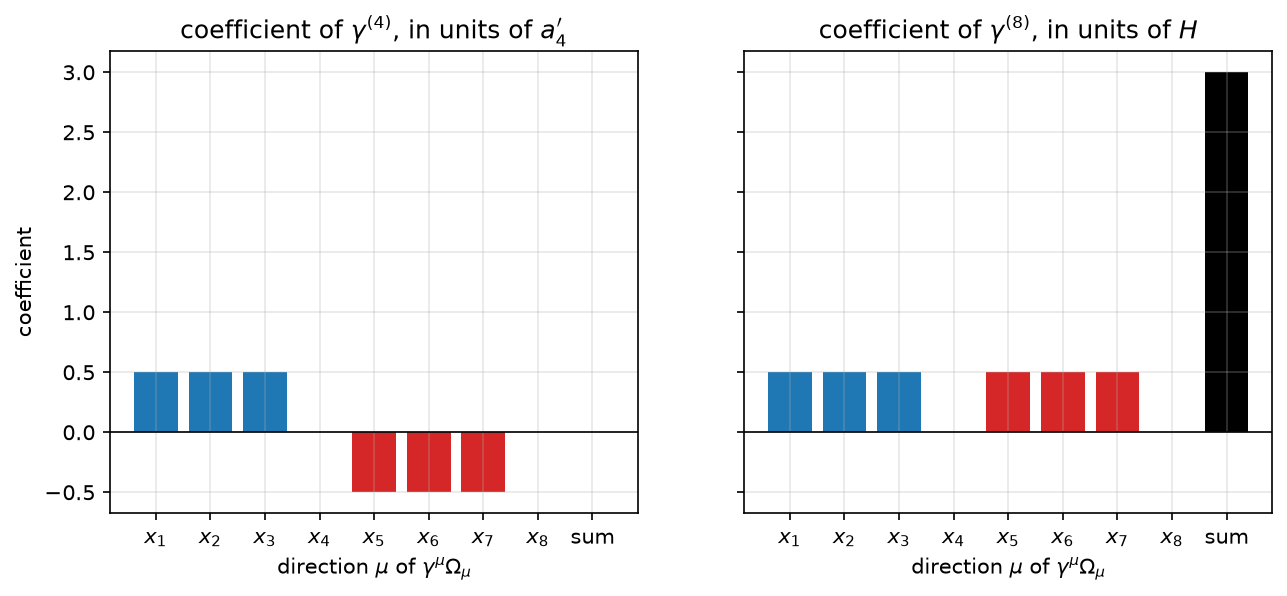

Figure 08c.1 saved as Revision/textbook/figures/08c_1_cancel_and_survive.png


In [6]:
per_direction = [(diagonal["gamma"][mu] * diagonal["Omega"][mu]).applyfunc(sp.simplify)
                 for mu in range(8)]
coefficient_4 = [sp.simplify(-(G[3] * M).trace() / 16) for M in per_direction]
coefficient_8 = [sp.simplify((G[7] * M).trace() / 16) for M in per_direction]
nothing_else = all(
    all(is_zero(entry) for entry in
        per_direction[mu] - coefficient_4[mu] * G[3] - coefficient_8[mu] * G[7])
    for mu in range(8))
for mu in range(8):
    say(f"gamma^x{mu + 1} Omega_x{mu + 1} = ({coefficient_4[mu]}) gamma^(x4) "
        f"+ ({coefficient_8[mu]}) gamma^(x8)")
check(nothing_else, "each gamma^mu Omega_mu (no sum) is a combination of gamma^(x4) "
      "and gamma^(x8)")
THEORY = "Revision/theory/reports/python-field-theory.json"  # the sympy record
# The record writes A1 for a4'; the partial sums in the record's notation:
inflating_sum = sp.simplify(sum(coefficient_4[:3])).subs(a4_prime, A1)  # 3*A1/2
deflating_sum = sp.simplify(sum(coefficient_4[4:7])).subs(a4_prime, A1)  # -3*A1/2
hidden_sum = sp.simplify(sum(coefficient_8))  # 3*H
say(f"sums: inflating {inflating_sum}, deflating {deflating_sum}, hidden {hidden_sum}")
check_record([sp.simplify(c4 / a4_prime) for c4 in coefficient_4]
             == [sp.Rational(1, 2)] * 3 + [0] + [-sp.Rational(1, 2)] * 3 + [0]
             and [sp.simplify(c8 / H) for c8 in coefficient_8]
             == [sp.Rational(1, 2)] * 3 + [0] + [sp.Rational(1, 2)] * 3 + [0],
             "per direction: +a4'/2 and -a4'/2 cancel, six times H/2 add up",
             THEORY, "time_terms_cancel_hidden_term_survives",
             f"inflating sum {inflating_sum}, deflating sum {deflating_sum}",
             f"the six hidden-direction terms add to {hidden_sum} gamma^(x8)")
total = sum(per_direction, sp.zeros(16, 16))
check_record(all(is_zero(entry) for entry in total - 3 * H * G[7]),
             "gamma^mu Omega_mu = 3 H gamma^(x8) in the diagonal frame",
             THEORY, "gamma_mu_Omega_mu_equals_3H_gamma_x8",
             "gamma^mu Omega_mu = 3 H gamma^(x8) exactly")
# gamma^(x8) squares to 1, so it is invertible: 3 H gamma^(x8) Psi = 0 only for
# Psi = 0. The gravitational term is not zero for any field Psi that is not zero.
check_record(G[7] * G[7] == sp.eye(16),
             "(gamma^(x8))^2 = 1: 3 H gamma^(x8) Psi != 0 for every Psi != 0 (H > 0)",
             "Revision/theory/reports/wolfram-field-theory.json",
             "nontriviality_1_dirac16complex",
             "every Psi != 0 (gamma^(x8) is invertible)")
sqrt_g = sp.cos(z)
divergence = sum((sp.diff(sqrt_g * diagonal["gamma"][mu], x[mu]) for mu in range(8)),
                 sp.zeros(16, 16)) / (2 * sqrt_g)
check_record(all(is_zero(entry) for entry in divergence - 3 * H * G[7]),
             "(1/(2 sqrt|g|)) d_mu(sqrt|g| gamma^mu) = 3 H gamma^(x8) (divergence "
             "form)", THEORY, "divergence_of_sqrtg_gamma",
             "= 3 H gamma^(x8) = gamma^mu Omega_mu")
check_record(all(all(is_zero(entry) for entry in
                     diagonal["gamma"][mu] * diagonal["Omega"][mu]
                     + diagonal["Omega"][mu] * diagonal["gamma"][mu])
                 for mu in range(8)),
             "{gamma^mu, Omega_mu} = 0 for each mu: Omega drops out of the Lagrangian",
             "Revision/theory/reports/python-scope.json",
             "connection_free_lagrangian_same_equations",
             "{gamma^mu, Omega_mu} = 0 for each mu separately")

names = [f"$x_{mu + 1}$" for mu in range(8)] + ["sum"]
values_4 = [float(sp.simplify(c4 / a4_prime)) for c4 in coefficient_4]
values_8 = [float(sp.simplify(c8 / H)) for c8 in coefficient_8]
values_4.append(sum(values_4))
values_8.append(sum(values_8))
colours = ["tab:blue"] * 3 + ["gray"] + ["tab:red"] * 3 + ["gray", "black"]
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0), sharey=True)
left.bar(names, values_4, color=colours)
left.set_title("coefficient of $\\gamma^{(4)}$, in units of $a_4'$")
left.set_ylabel("coefficient")
right.bar(names, values_8, color=colours)
right.set_title("coefficient of $\\gamma^{(8)}$, in units of $H$")
for panel in (left, right):
    panel.axhline(0.0, color="black", linewidth=0.8)
    panel.set_xlabel("direction $\\mu$ of $\\gamma^{\\mu}\\Omega_{\\mu}$")
save_figure(fig, "cancel_and_survive",
            "The term $\\gamma^\\mu\\Omega_\\mu$ of the field equation in the "
            "diagonal frame, direction by direction (no sum) and summed (black). "
            "Left: the coefficient of $\\gamma^{(4)}$ in units of $a_4'$; the three "
            "inflating directions $x_1, x_2, x_3$ (blue) give $+1/2$ each, the three "
            "deflating extra times $x_5, x_6, x_7$ (red) give $-1/2$ each, $x_4$ and "
            "$x_8$ (gray) give 0, and the sum is 0. Right: the coefficient of "
            "$\\gamma^{(8)}$ in units of $H$; the same six directions give $+1/2$ "
            "each and the sum is $3$. Exact values from sympy, valid for every "
            "history $a_4$ and every $H > 0$.")

## 10. The deflation is invisible in this term, but not in the curvature

The term $3H\gamma^{(8)}$ contains no $a_4$: the deflation of the extra times does
not show up in it. The geometry of the $a_4$ sector is nevertheless curved. The
next cell computes the Riemann tensor from the Christoffel symbols,
$R^\rho{}_{\sigma\mu\nu} = \partial_\mu\Gamma^\rho{}_{\nu\sigma} -
\partial_\nu\Gamma^\rho{}_{\mu\sigma} + \sum_\lambda(\Gamma^\rho{}_{\mu\lambda}
\Gamma^\lambda{}_{\nu\sigma} - \Gamma^\rho{}_{\nu\lambda}\Gamma^\lambda{}_{\mu\sigma})$,
and the diagonal Ricci components $R^{x_a}{}_{x_a}$, and checks them against the
record: $a_4'' - 6H^2$ (3-space), $6(a_4')^2$ (time), $-a_4'' - 6H^2$ (extra
times), $-6H^2$ (hidden direction), and $R = 6((a_4')^2 - 7H^2)$. Then it draws,
along the canonical history $a_4 = x_4$ at $z = \pi/4$ and $H = 1$, two pieces of
the connection (they change exponentially) and the two partial sums of the
$\gamma^{(4)}$ coefficients (they stay constant and cancel).

PASS R^x1_x1 = a4'' - 6H^2, R^x4_x4 = 6 a4'^2, R^x5_x5 = -a4'' - 6H^2, R^x8_x8 = -6H^2
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    ricci_mixed_components
Ricci scalar in the record's notation: R = 6*(A1**2 - 7*H**2)
PASS Ricci scalar R = 6 (a4'^2 - 7 H^2): curved for every H > 0
     reproduces Revision/theory/reports/python-field-theory.json, check
    curvature_nonzero_flat_only_formally
PASS gamma^mu Omega_mu contains no a4, although R^x4_x4 = 6 a4'^2 is not zero
     reproduces Revision/theory/reports/python-scope.json, check
    gammaOmega_blind_to_the_deflation


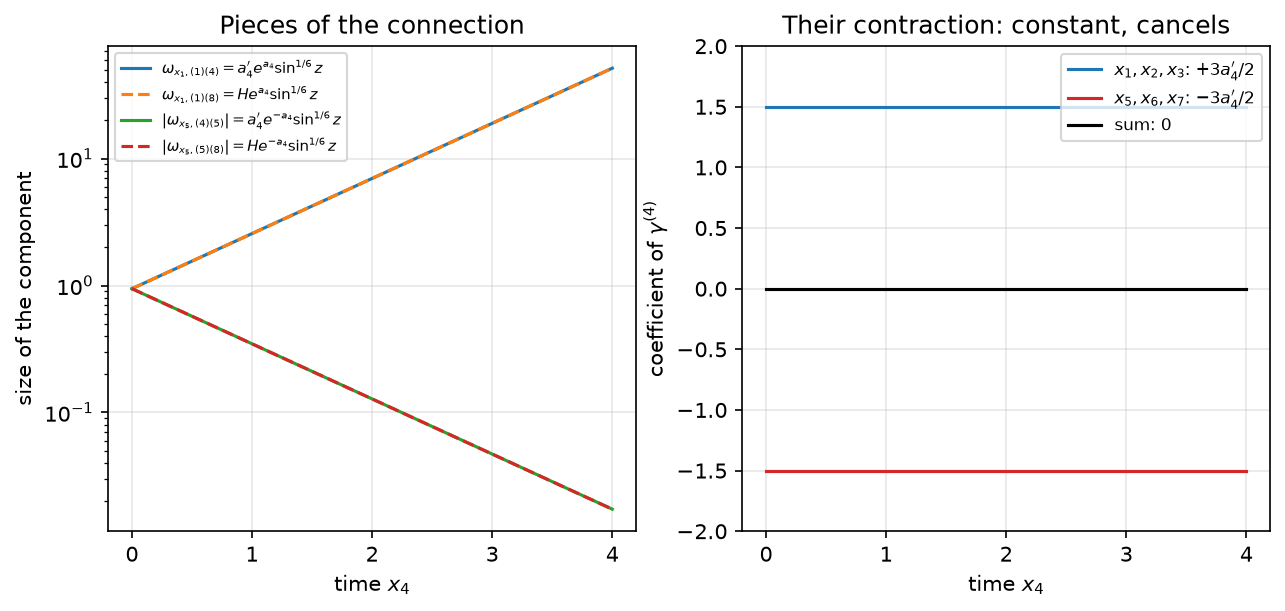

Figure 08c.2 saved as Revision/textbook/figures/08c_2_pieces_along_history.png


In [7]:
def riemann(rho, sigma, mu, nu):
    """R^rho_sigma,mu,nu from the Christoffel symbols (not simplified)."""
    value = sp.diff(Gam[rho][nu][sigma], x[mu]) - sp.diff(Gam[rho][mu][sigma], x[nu])
    for lam in range(8):
        value += Gam[rho][mu][lam] * Gam[lam][nu][sigma] \
            - Gam[rho][nu][lam] * Gam[lam][mu][sigma]
    return value


ricci = [sum(riemann(rho, a, rho, a) for rho in range(8)) / g[a] for a in range(8)]
a4_second = sp.diff(a4, x[3], 2)
expected = [a4_second - 6 * H**2] * 3 + [6 * a4_prime**2] \
    + [-a4_second - 6 * H**2] * 3 + [-6 * H**2]
check_record(all(is_zero(ricci[a] - expected[a]) for a in range(8)),
             "R^x1_x1 = a4'' - 6H^2, R^x4_x4 = 6 a4'^2, R^x5_x5 = -a4'' - 6H^2, "
             "R^x8_x8 = -6H^2", "Revision/theory/reports/wolfram-field-theory.json",
             "ricci_mixed_components", "R^1_1 = R^2_2 = R^3_3 = a4'' - 6 H^2",
             "R^4_4 = 6 a4'^2", "R^5_5 = R^6_6 = R^7_7 = -a4'' - 6 H^2",
             "R^8_8 = -6 H^2")
ricci_scalar = sp.factor(sp.simplify(sum(ricci)).subs(a4_prime, A1))  # A1 for a4'
say(f"Ricci scalar in the record's notation: R = {ricci_scalar}")
check_record(is_zero(sum(ricci) - 6 * (a4_prime**2 - 7 * H**2)),
             "Ricci scalar R = 6 (a4'^2 - 7 H^2): curved for every H > 0",
             THEORY, "curvature_nonzero_flat_only_formally",
             f"Ricci scalar R = {sp.sstr(ricci_scalar)}")
check_record(not total.applyfunc(sp.simplify).has(a4) and not is_zero(ricci[3]),
             "gamma^mu Omega_mu contains no a4, although R^x4_x4 = 6 a4'^2 is not zero",
             "Revision/theory/reports/python-scope.json",
             "gammaOmega_blind_to_the_deflation",
             "contains neither e^a4 nor a4' nor a4''", "R^x4_x4 = 6 a4'^2")

parameters = json.loads(repository_file(
    "Revision/kohn_sham/results/parameters.json").read_text(encoding="utf-8"))
A_history = parameters["physics"]["historyA"]  # the canonical history a4 = A H x4
history = sp.Lambda(x[3], A_history * x[3])  # with H = 1: a4 = x4


def along_history(expr):
    """A numpy function of x4 for expr with H = 1, a4 = A x4, z = pi/4."""
    concrete = expr.replace(sp.Function("a4"), history).doit()
    concrete = concrete.subs({H: 1, x[7]: sp.pi / 24})  # z = 6 x8 = pi/4
    return sp.lambdify(x[3], concrete, "numpy")


times = np.linspace(0.0, 4.0, 201)
pieces = {"$\\omega_{x_1,(1)(4)} = a_4'e^{a_4}\\sin^{1/6}z$": diagonal["omega"][0, 0, 3],
          "$\\omega_{x_1,(1)(8)} = He^{a_4}\\sin^{1/6}z$": diagonal["omega"][0, 0, 7],
          "$|\\omega_{x_5,(4)(5)}| = a_4'e^{-a_4}\\sin^{1/6}z$":
              -ETA[3] * diagonal["omega"][4, 3, 4],
          "$|\\omega_{x_5,(5)(8)}| = He^{-a_4}\\sin^{1/6}z$":
              ETA[4] * diagonal["omega"][4, 4, 7]}
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.2))
for (label, expr), style in zip(pieces.items(), ("-", "--", "-", "--")):
    left.plot(times, np.abs(along_history(expr)(times)) * np.ones_like(times),
              style, label=label)
left.set_yscale("log")
left.set_xlabel("time $x_4$")
left.set_ylabel("size of the component")
left.set_title("Pieces of the connection")
left.legend(fontsize=7)
inflating = along_history(sum(coefficient_4[:3]))(times) * np.ones_like(times)
deflating = along_history(sum(coefficient_4[4:7]))(times) * np.ones_like(times)
right.plot(times, inflating, color="tab:blue", label="$x_1, x_2, x_3$: $+3a_4'/2$")
right.plot(times, deflating, color="tab:red", label="$x_5, x_6, x_7$: $-3a_4'/2$")
right.plot(times, inflating + deflating, color="black", label="sum: $0$")
right.set_ylim(-2.0, 2.0)
right.set_xlabel("time $x_4$")
right.set_ylabel("coefficient of $\\gamma^{(4)}$")
right.set_title("Their contraction: constant, cancels")
right.legend(fontsize=8);
save_figure(fig, "pieces_along_history",
            "Along the canonical history $a_4 = x_4$ of the Kohn-Sham record ($A = "
            "H = 1$, a prescribed background) at $z = \\pi/4$, against the time "
            "$x_4$. Left, on a logarithmic axis: four components of the canonical "
            "spin connection of the diagonal frame; those of the inflating "
            "direction $x_1$ grow like $e^{a_4}$, those of the deflating extra time "
            "$x_5$ shrink like $e^{-a_4}$; the dashed ones (factor $H$) lie on the "
            "solid ones (factor $a_4'$) because here $a_4' = AH = H = 1$. Right: "
            "the coefficient of $\\gamma^{(4)}$ in $\\gamma^\\mu\\Omega_\\mu$ summed "
            "over the three inflating "
            "directions (blue, $+3a_4'/2$) and over the three extra times (red, "
            "$-3a_4'/2$): the frame factors cancel the exponentials, both partial "
            "sums stay constant, and they cancel exactly (black).")

## 11. The boosted frame: the term depends on the frame

The next cell builds the frame boosted by the rapidity $b = \beta x_4 + b_0$ with
symbolic $\beta$ and $b_0$. It checks that the new frame gives the SAME metric
($\sum_a\eta_{aa}e'^a{}_\mu e'^a{}_\nu = g_{\mu\nu}$ for all 64 pairs) and that its
canonical connection obeys the vielbein postulate, and then that
$\gamma'^\mu\Omega'_\mu = \frac{6H - \beta}{2}(\cosh b\,\gamma^{(8)} -
\sinh b\,\gamma^{(4)})$ exactly. For $\beta = 6H$ this is ZERO for every $H$ and
every $a_4$, although the spinor connections $\Omega'_\mu$ themselves are not zero
(for $\mu = x_1, \dots, x_7$). The 28 matrices $S^{ab}$ ($a < b$) are linearly
independent (rank 28, checked in section 8), so $\Omega'_\mu$ is zero exactly when
all its coefficients $\omega'_{\mu ab}$ are. Every check also compares with the
text of the Revision record (for example the formula of
$\gamma'^\mu\Omega'_\mu$ and the list of the directions with $\Omega'_\mu \neq 0$).

In [8]:
rapidity = beta * x[3] + b0
boosted = frame(rapidity)
e_b = boosted["e"]
same_metric = all(
    is_zero(sum(ETA[a] * e_b[a, mu] * e_b[a, nu] for a in range(8))
            - (g[mu] if mu == nu else 0)) for mu in range(8) for nu in range(8))
SCOPE = "Revision/theory/reports/python-scope.json"  # the record of these checks
check_record(same_metric and all(is_zero(v) for v in e_b * boosted["E"] - sp.eye(8)),
             "the boosted frame gives the same metric (64 entries); e' E' = 1",
             SCOPE, "boosted_frame_reproduces_metric",
             "equals the author's metric for all 64 (mu, nu)")
failures = postulate_failures(boosted)  # the number of nonzero components
check_record(failures == 0 and antisymmetric(boosted),
             "boosted frame: vielbein postulate (512 components), omega' antisymmetric",
             SCOPE, "boosted_frame_canonical_connection",
             f"holds for all 512 (a, mu, nu) ({failures} failures)")
total_boosted = sum((boosted["gamma"][mu] * boosted["Omega"][mu] for mu in range(8)),
                    sp.zeros(16, 16))
formula = (6 * H - beta) / 2 * (sp.cosh(rapidity) * G[7] - sp.sinh(rapidity) * G[3])
check_record(all(is_zero(entry) for entry in total_boosted - formula),
             "gamma'^mu Omega'_mu = ((6H - beta)/2) (cosh b gamma^(x8) - sinh b "
             "gamma^(x4))", SCOPE, "boosted_frame_gammaOmega_formula",
             "gamma'^mu Omega'_mu = ((6 H - beta)/2) (cosh b gamma^(x8) - sinh b "
             "gamma^(x4))")
at_6H = {beta: 6 * H}
nonzero_Omega = [mu for mu in range(8) if not all(
    is_zero(ETA[a] * boosted["omega"][mu, a, c].subs(at_6H))
    for a in range(8) for c in range(a + 1, 8))]
nonzero_text = ", ".join(f"x{mu + 1}" for mu in nonzero_Omega)  # "x1, x2, ..."
say("beta = 6H: Omega'_mu is nonzero for mu = " + nonzero_text)
check_record(all(is_zero(entry.subs(at_6H)) for entry in total_boosted - formula)
             and formula.subs(at_6H) == sp.zeros(16, 16)
             and nonzero_Omega == [0, 1, 2, 3, 4, 5, 6],
             "beta = 6H: gamma'^mu Omega'_mu = 0 identically, Omega'_mu != 0 for "
             "x1..x7", SCOPE, "boosted_frame_gammaOmega_vanishes", "IDENTICALLY ZERO",
             f"nonzero for mu = {nonzero_text} (zero only for x8)")

PASS the boosted frame gives the same metric (64 entries); e' E' = 1
     reproduces Revision/theory/reports/python-scope.json, check
    boosted_frame_reproduces_metric
PASS boosted frame: vielbein postulate (512 components), omega' antisymmetric
     reproduces Revision/theory/reports/python-scope.json, check
    boosted_frame_canonical_connection
PASS gamma'^mu Omega'_mu = ((6H - beta)/2) (cosh b gamma^(x8) - sinh b gamma^(x4))
     reproduces Revision/theory/reports/python-scope.json, check
    boosted_frame_gammaOmega_formula
beta = 6H: Omega'_mu is nonzero for mu = x1, x2, x3, x4, x5, x6, x7
PASS beta = 6H: gamma'^mu Omega'_mu = 0 identically, Omega'_mu != 0 for x1..x7
     reproduces Revision/theory/reports/python-scope.json, check
    boosted_frame_gammaOmega_vanishes


The next cell draws the size of the term, $\lVert M\rVert = \sqrt{\mathrm{tr}
(M^TM)/16}$ (for $M = \gamma^{(8)}$ this is 1), for $H = 1$: on the left against
$\beta$ at $x_4 = 0$, $b_0 = 0$; on the right against $x_4$ for four values of
$\beta$. The cell evaluates the formula, which the previous cell showed to be
equal, entry by entry, to the computed matrix $\gamma'^\mu\Omega'_\mu$.

PASS size 3 in the diagonal frame (3 H gamma^(x8), H = 1), 0 for beta = 6H


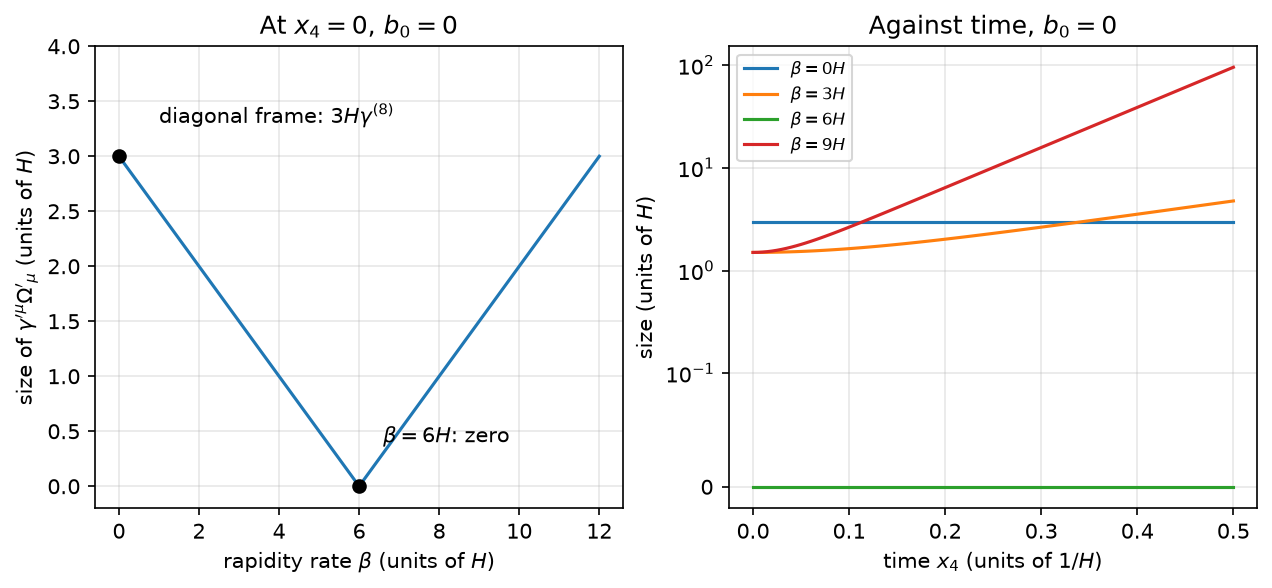

Figure 08c.3 saved as Revision/textbook/figures/08c_3_boost_size.png


In [9]:
term = sp.lambdify((beta, x[3], b0), formula.subs(H, 1), "numpy")


def size(matrix):
    """sqrt(tr(M^T M)/16): the size of a 16 x 16 matrix, 1 for gamma^(x8)."""
    matrix = np.array(matrix, dtype=float)
    return np.sqrt(np.trace(matrix.T @ matrix) / 16)


beta_values = np.linspace(0.0, 12.0, 241)
sizes_beta = [size(term(bv, 0.0, 0.0)) for bv in beta_values]
check(abs(size(term(0.0, 0.0, 0.0)) - 3.0) < 1e-12 and size(term(6.0, 0.7, 0.3)) == 0,
      "size 3 in the diagonal frame (3 H gamma^(x8), H = 1), 0 for beta = 6H")
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
left.plot(beta_values, sizes_beta)
left.plot([0.0, 6.0], [3.0, 0.0], "o", color="black")
left.annotate("diagonal frame: $3H\\gamma^{(8)}$", (0.0, 3.0), (1.0, 3.3))
left.annotate("$\\beta = 6H$: zero", (6.0, 0.0), (6.6, 0.4))
left.set_xlabel("rapidity rate $\\beta$ (units of $H$)")
left.set_ylabel("size of $\\gamma'^\\mu\\Omega'_\\mu$ (units of $H$)")
left.set_title("At $x_4 = 0$, $b_0 = 0$")
left.set_ylim(-0.2, 4.0)
times = np.linspace(0.0, 0.5, 101)
for bv in (0.0, 3.0, 6.0, 9.0):
    right.plot(times, [size(term(bv, t, 0.0)) for t in times],
               label=f"$\\beta = {bv:g}H$")
right.set_yscale("symlog", linthresh=0.1)
right.set_xlabel("time $x_4$ (units of $1/H$)")
right.set_ylabel("size (units of $H$)")
right.set_title("Against time, $b_0 = 0$")
right.legend(fontsize=8);
save_figure(fig, "boost_size",
            "The size $\\sqrt{\\mathrm{tr}(M^TM)/16}$ of the term $M = "
            "\\gamma'^\\mu\\Omega'_\\mu$ of the field equation in the frame boosted "
            "in the $(x_4, x_8)$ plane with rapidity $b = \\beta x_4 + b_0$, for "
            "$H = 1$; sizes in units of $H$. Left: against the rapidity rate "
            "$\\beta$ at $x_4 = 0$, $b_0 = 0$; the diagonal frame ($\\beta = 0$) "
            "gives $3$, the value of $3H\\gamma^{(8)}$, and the size $|6H - "
            "\\beta|/2$ falls to zero at $\\beta = 6H$. Right: against the time "
            "$x_4$ (symmetric logarithmic axis) for $\\beta = 0, 3H, 6H, 9H$; for "
            "$\\beta = 6H$ the term is zero at all times. The metric is the same in "
            "every one of these frames.")

The next cell draws the $16 \times 16$ matrices themselves as colour maps (red
positive, blue negative, white zero): $\gamma^\mu\Omega_\mu$ of the diagonal frame,
$\gamma'^\mu\Omega'_\mu$ for $\beta = 3H$ at $x_4 = 0.3$, and for $\beta = 6H$
(zero), with $H = 1$, $b_0 = 0$.

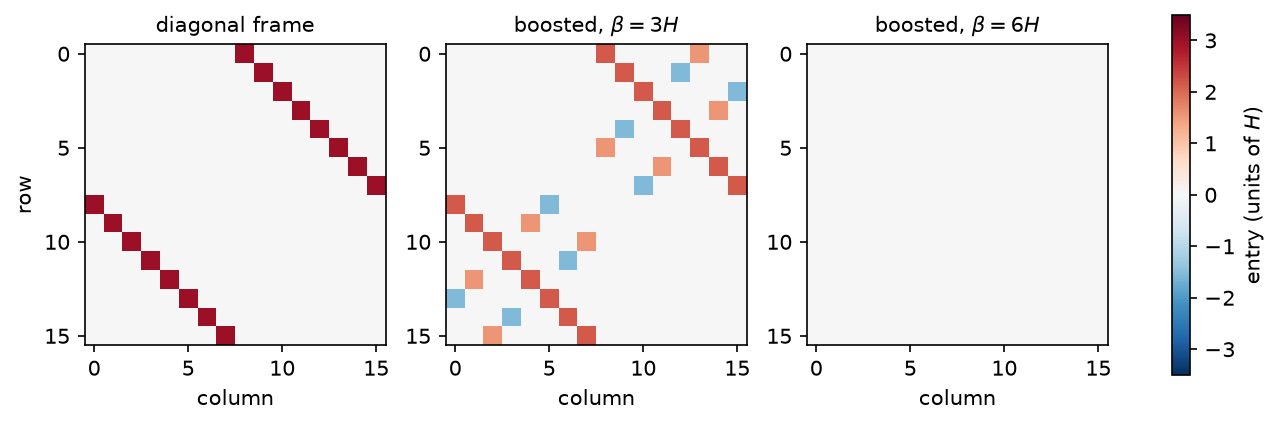

Figure 08c.4 saved as Revision/textbook/figures/08c_4_heat_maps.png


In [10]:
maps = [("diagonal frame", term(0.0, 0.3, 0.0)),
        ("boosted, $\\beta = 3H$", term(3.0, 0.3, 0.0)),
        ("boosted, $\\beta = 6H$", term(6.0, 0.3, 0.0))]
fig, panels = plt.subplots(1, 3, figsize=(11.0, 3.9))
for panel, (title, matrix) in zip(panels, maps):
    image = panel.imshow(np.array(matrix, dtype=float), cmap="RdBu_r", vmin=-3.5,
                         vmax=3.5)
    panel.set_title(title, fontsize=10)
    panel.set_xticks([0, 5, 10, 15])
    panel.set_yticks([0, 5, 10, 15])
    panel.set_xlabel("column")
    panel.grid(False)  # no grid lines over the coloured squares
panels[0].set_ylabel("row")
fig.colorbar(image, ax=list(panels), shrink=0.8, label="entry (units of $H$)")
save_figure(fig, "heat_maps",
            "The $16 \\times 16$ matrix $\\gamma^\\mu\\Omega_\\mu$ of the field "
            "equation as a colour map (rows and columns numbered from 0; red "
            "positive, blue negative, white zero; entries in units of $H$, $H = 1$, "
            "time $x_4 = 0.3$, $b_0 = 0$). Left: diagonal frame, $3H\\gamma^{(8)}$, "
            "sixteen entries equal to 3. Middle: frame boosted with $\\beta = 3H$, "
            "$\\frac{3H}{2}(\\cosh b\\,\\gamma^{(8)} - \\sinh b\\,\\gamma^{(4)})$ "
            "with $b = 0.9$. Right: frame boosted with $\\beta = 6H$, the zero "
            "matrix. Same metric, same field equation, different frames.")

## 12. The connection itself vanishes in no frame: the curvature

If $\Omega'_\mu$ were zero in some frame, the spinor curvature $F_{\mu\nu} =
\partial_\mu\Omega_\nu - \partial_\nu\Omega_\mu + [\Omega_\mu, \Omega_\nu]$ would
be zero there. The next cell computes $F_{x_1x_8}$ in the diagonal frame and in the
frame boosted with $\beta = 6H$ (where $\gamma'^\mu\Omega'_\mu = 0$) and checks:

1. in both frames $F_{x_1x_8} = \frac14\sum_{\rho,\sigma}R_{\rho\sigma x_1x_8}
   \gamma^\rho\gamma^\sigma$ with $R_{\rho\sigma\mu\nu} =
   g_{\rho\rho}R^\rho{}_{\sigma\mu\nu}$: the curvature of the connection is the
   Riemann tensor of the metric;
2. in both frames $F_{x_1x_8} = c_{14}\,\gamma^{(1)}\gamma^{(4)} +
   c_{18}\,\gamma^{(1)}\gamma^{(8)}$ with two numbers $c_{14}, c_{18}$ (found as
   traces, like the coefficients of section 9, and printed);
3. hence $F_{x_1x_8}^2 = (c_{14}^2 - c_{18}^2)\,I_{16}$, because
   $(\gamma^{(1)}\gamma^{(4)})^2 = +1$, $(\gamma^{(1)}\gamma^{(8)})^2 = -1$ and the
   two products anticommute; and $c_{14}^2 - c_{18}^2$ is the SAME in both frames,
   $H^2\big((a_4')^2 - H^2\big)e^{2a_4}\cos^2 z/(4\sin^{5/3}z)$. It must be: the
   matrices $\gamma^\rho$ and $\gamma'^\rho$ of the two frames obey the same
   relations $\{\gamma^\rho, \gamma^\sigma\} = 2g^{\rho\sigma}$, so (because the
   16-dimensional representation is irreducible; Pauli's theorem) there is an
   invertible $16 \times 16$ matrix $S$ with $\gamma'^\rho = S\gamma^\rho S^{-1}$,
   and then $F' = SFS^{-1}$ and $F'^2 = SF^2S^{-1} = F^2$;
4. $F'_{x_1x_8}$ is not zero.

Since the Riemann tensor does not depend on the frame and is not zero, no frame can
remove $\Omega_\mu$.

In [11]:
def spinor_curvature(fr):
    """F_x1x8 = d_1 Omega_8 - d_8 Omega_1 + [Omega_1, Omega_8]."""
    O1, O8 = fr["Omega"][0], fr["Omega"][7]
    return sp.diff(O8, x[0]) - sp.diff(O1, x[7]) + O1 * O8 - O8 * O1


def riemann_side(fr):
    """(1/4) sum R_rho,sigma,x1,x8 gamma^rho gamma^sigma in the frame fr."""
    result = sp.zeros(16, 16)
    for rho in range(8):
        for sigma in range(8):
            value = g[rho] * riemann(rho, sigma, 0, 7)  # lower the first index
            if value != 0:
                result += value * fr["gamma"][rho] * fr["gamma"][sigma] / 4
    return result


P14, P18 = G[0] * G[3], G[0] * G[7]  # gamma^(1) gamma^(4) and gamma^(1) gamma^(8)


def two_coefficients(F):
    """c14, c18 with F = c14 P14 + c18 P18 (P14^2 = 1, P18^2 = -1), and whether
    nothing else is left."""
    c14 = sp.simplify((P14 * F).trace() / 16)
    c18 = sp.simplify(-(P18 * F).trace() / 16)
    return c14, c18, all(is_zero(v) for v in F - c14 * P14 - c18 * P18)


zero_frame = {"Omega": [M.subs(at_6H) for M in boosted["Omega"]],  # beta = 6H
              "gamma": [M.subs(at_6H) for M in boosted["gamma"]]}
F_diagonal = spinor_curvature(diagonal)
F_zero = spinor_curvature(zero_frame)
check_record(all(is_zero(v) for v in F_diagonal - riemann_side(diagonal)),
             "diagonal frame: F_x1x8 = (1/4) R_rho,sigma,x1,x8 gamma^rho gamma^sigma",
             THEORY, "spinor_curvature_equals_riemann",
             "= (1/4) R_{rho sigma mu nu} gamma^rho gamma^sigma")
check(all(is_zero(v) for v in F_zero - riemann_side(zero_frame)),
      "boosted frame (beta = 6H): F'_x1x8 = (1/4) R gamma'^rho gamma'^sigma")
c14, c18, only_two = two_coefficients(F_diagonal)
c14_b, c18_b, only_two_b = two_coefficients(F_zero)
say(f"diagonal frame: c14 = {c14}")
say(f"diagonal frame: c18 = {c18}")
say(f"boosted frame:  c14 = {c14_b}")
say(f"boosted frame:  c18 = {c18_b}")
check(only_two and only_two_b,
      "in both frames F_x1x8 = c14 gamma^(1) gamma^(4) + c18 gamma^(1) gamma^(8)")
kappa_F = H**2 * (a4_prime**2 - H**2) * sp.exp(2 * a4) * sp.cos(z) ** 2 \
    / (4 * sp.sin(z) ** sp.Rational(5, 3))
check(is_zero(c14**2 - c18**2 - kappa_F) and is_zero(c14_b**2 - c18_b**2 - kappa_F),
      "F^2 = F'^2 = H^2 (a4'^2 - H^2) e^(2 a4) cos^2 z / (4 sin^(5/3) z) I16 in "
      "both frames")
entries_nonzero = sum(1 for v in F_zero if not is_zero(v))
report("nonzero entries of F'_x1x8 in the frame with gamma'^mu Omega'_mu = 0",
       entries_nonzero)
check_record(entries_nonzero > 0, "beta = 6H: the spinor curvature F'_x1x8 is not "
             "zero", "Revision/theory/reports/python-scope.json",
             "boosted_frame_curvature_nonzero",
             "F'_x1x8 = d_x1 Omega'_x8 - d_x8 Omega'_x1 + [Omega'_x1, Omega'_x8] is "
             "nonzero")

PASS diagonal frame: F_x1x8 = (1/4) R_rho,sigma,x1,x8 gamma^rho gamma^sigma
     reproduces Revision/theory/reports/python-field-theory.json, check
    spinor_curvature_equals_riemann
PASS boosted frame (beta = 6H): F'_x1x8 = (1/4) R gamma'^rho gamma'^sigma
diagonal frame: c14 = -H*exp(a4(x4))*cos(6*H*x8)*Derivative(a4(x4),
    x4)/(2*sin(6*H*x8)**(5/6))
diagonal frame: c18 = -H**2*exp(a4(x4))*cos(6*H*x8)/(2*sin(6*H*x8)**(5/6))
boosted frame:  c14 = H*(H*sinh(6*H*x4 + b0) - cosh(6*H*x4 + b0)*Derivative(a4(x4),
    x4))*exp(a4(x4))*cos(6*H*x8)/(2*sin(6*H*x8)**(5/6))
boosted frame:  c18 = -H*(H*cosh(6*H*x4 + b0) - sinh(6*H*x4 + b0)*Derivative(a4(x4),
    x4))*exp(a4(x4))*cos(6*H*x8)/(2*sin(6*H*x8)**(5/6))
PASS in both frames F_x1x8 = c14 gamma^(1) gamma^(4) + c18 gamma^(1) gamma^(8)
PASS F^2 = F'^2 = H^2 (a4'^2 - H^2) e^(2 a4) cos^2 z / (4 sin^(5/3) z) I16 in both frames
RESULT nonzero entries of F'_x1x8 in the frame with gamma'^mu Omega'_mu = 0 = 32
PASS beta = 6H: the spinor curvature 

The next cell draws $F_{x_1x_8}$ in both frames as colour maps, at $H = 1$,
$z = \pi/4$, $x_4 = 0.5$, $b_0 = 0$, along the canonical history $a_4 = x_4$. On
this history $a_4' = AH = H$, so $c_{14}^2 - c_{18}^2 = 0$: the matrix $F_{x_1x_8}$
is NOT zero, but its square is zero (a *nilpotent* matrix, like the $2 \times 2$
matrix with rows $(0, 1)$ and $(0, 0)$); similar matrices have the same rank, and
the cell checks that both have rank 8. Moreover, with $a_4' = H$ the printed
boosted coefficients are $e^{-b}$ times the diagonal ones ($\cosh b - \sinh b =
e^{-b}$), so $F' = e^{-b}F$ at this point, with $b = 6Hx_4 = 3$; the cell checks
this too. The entries of the right map are therefore about $e^{-3} \approx 0.05$
times those of the left one; each map has its own colour scale.

RESULT largest entry of F_x1x8 at the point (diagonal, boosted) = 0.778093, 0.038739
RESULT rank of F_x1x8 at the point (diagonal, boosted) = [8, 8]
PASS a4 = x4: F and F' have rank 8 and square 0, and F' = e^(-3) F at x4 = 0.5


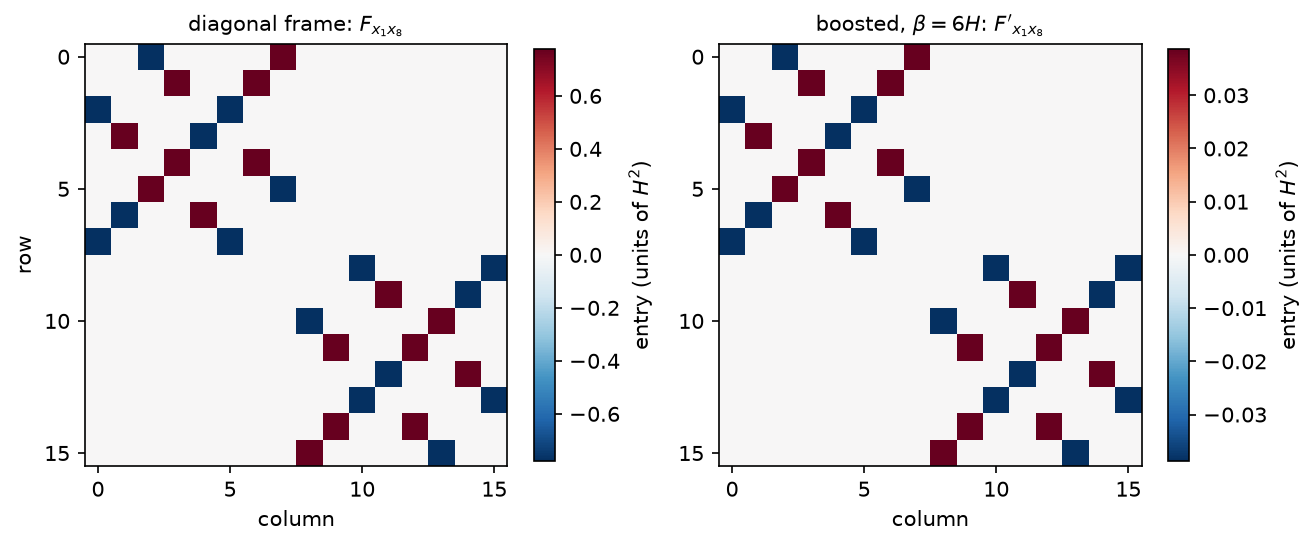

Figure 08c.5 saved as Revision/textbook/figures/08c_5_curvature_maps.png


In [12]:
def at_point(matrix):
    """The numbers of a symbolic matrix at H = 1, a4 = x4, z = pi/4, x4 = 0.5."""
    concrete = matrix.replace(sp.Function("a4"), history).doit()
    concrete = concrete.subs({H: 1, x[7]: sp.pi / 24, x[3]: sp.Rational(1, 2), b0: 0})
    return np.array(concrete.evalf(), dtype=float)


F_numbers = [("diagonal frame: $F_{x_1x_8}$", at_point(F_diagonal)),
             ("boosted, $\\beta = 6H$: $F'_{x_1x_8}$", at_point(F_zero))]
report("largest entry of F_x1x8 at the point (diagonal, boosted)",
       ", ".join(f"{np.abs(matrix).max():.6f}" for _, matrix in F_numbers))
ranks = [int(np.linalg.matrix_rank(matrix)) for _, matrix in F_numbers]
squares = [np.abs(matrix @ matrix).max() for _, matrix in F_numbers]
report("rank of F_x1x8 at the point (diagonal, boosted)", ranks)
check(ranks == [8, 8] and max(squares) < 1e-14 and
      np.allclose(F_numbers[1][1], np.exp(-3.0) * F_numbers[0][1], atol=1e-14),
      "a4 = x4: F and F' have rank 8 and square 0, and F' = e^(-3) F at x4 = 0.5")
fig, panels = plt.subplots(1, 2, figsize=(10.0, 4.2))
for panel, (title, matrix) in zip(panels, F_numbers):
    largest = np.abs(matrix).max()  # each panel has its own colour scale
    image = panel.imshow(matrix, cmap="RdBu_r", vmin=-largest, vmax=largest)
    fig.colorbar(image, ax=panel, shrink=0.85, label="entry (units of $H^2$)")
    panel.set_title(title, fontsize=10)
    panel.set_xticks([0, 5, 10, 15])
    panel.set_yticks([0, 5, 10, 15])
    panel.set_xlabel("column")
    panel.grid(False)  # no grid lines over the coloured squares
panels[0].set_ylabel("row")
save_figure(fig, "curvature_maps",
            "The spinor curvature $F_{x_1x_8} = \\partial_1\\Omega_8 - "
            "\\partial_8\\Omega_1 + \\Omega_1\\Omega_8 - \\Omega_8\\Omega_1$ as a "
            "$16 \\times 16$ colour map (red positive, blue negative, white zero; "
            "units of $H^2$) at $H = 1$, $z = \\pi/4$, $x_4 = 0.5$ along the history "
            "$a_4 = x_4$; each panel has its own colour scale. Left: diagonal "
            "frame. Right: the frame boosted with $\\beta = 6H$, in which the term "
            "$\\gamma'^\\mu\\Omega'_\\mu$ of the field equation is identically zero; "
            "there the curvature is $e^{-3}$ times the left one. Neither is zero: "
            "the curvature equals one quarter of the Riemann tensor contracted "
            "with two gammas, so no choice of frame can make the spin connection "
            "vanish. On this history both matrices have rank 8 and square zero.")

## 13. The spin connection in the energy-momentum tensor

Although the connection drops out of the symmetrised Lagrangian (section 9), it
appears in the energy-momentum tensor. For a field that depends only on $x_4$,
the derivative part of $K^{x_4}{}_{x_1} = \frac12(\bar\Phi\gamma^{x_4}D_{x_1}\Phi -
(D_{x_1}\bar\Phi)\gamma^{x_4}\Phi)$ vanishes and the connection part is
$\frac12\bar\Phi\{\gamma^{x_4}, \Omega_{x_1}\}\Phi$. The next cell checks
$\frac12\{\gamma^{x_4}, \Omega_{x_1}\} = \frac12e^{a_4}\sin^{1/6}z\,H\,\gamma^{(4)}
\gamma^{(1)}\gamma^{(8)}$ (the $a_4'$ part cancels) and that the bilinear matrix
$C\gamma^{(4)}\gamma^{(1)}\gamma^{(8)}$ is not zero.

In [13]:
g4_up, Omega_1 = diagonal["gamma"][3], diagonal["Omega"][0]
connection_part = (g4_up * Omega_1 + Omega_1 * g4_up) / 2
target = sp.exp(a4) * sixth * H * G[3] * G[0] * G[7] / 2
check_record(all(is_zero(v) for v in connection_part - target)
             and C * G[3] * G[0] * G[7] != sp.zeros(16, 16),
             "(1/2){gamma^x4, Omega_x1} = (1/2) e^a4 sin^(1/6) z H gamma^(4) "
             "gamma^(1) gamma^(8), and C gamma^(4) gamma^(1) gamma^(8) != 0",
             "Revision/theory/reports/python-scope.json",
             "spin_connection_in_the_energy_momentum_tensor",
             "(1/2) e^a4 sin^(1/6) z H Phibar gamma^(x4) gamma^(x1) gamma^(x8) Phi",
             "C gamma^(x4) gamma^(x1) gamma^(x8) != 0")

PASS (1/2){gamma^x4, Omega_x1} = (1/2) e^a4 sin^(1/6) z H gamma^(4) gamma^(1) gamma^(8),
    and C gamma^(4) gamma^(1) gamma^(8) != 0
     reproduces Revision/theory/reports/python-scope.json, check
    spin_connection_in_the_energy_momentum_tensor


## 14. The last check

The last cell checks that the five figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [14]:
for name in ("08c_1_cancel_and_survive.png", "08c_2_pieces_along_history.png",
             "08c_3_boost_size.png", "08c_4_heat_maps.png", "08c_5_curvature_maps.png"):
    check(output_file(f"{FIGURE_FOLDER}/{name}").is_file(),
          f"the figure file {name} exists")
all_checks_passed()

PASS the figure file 08c_1_cancel_and_survive.png exists
PASS the figure file 08c_2_pieces_along_history.png exists
PASS the figure file 08c_3_boost_size.png exists
PASS the figure file 08c_4_heat_maps.png exists
PASS the figure file 08c_5_curvature_maps.png exists
ALL 32 CHECKS PASSED (notebook 08c)


## 15. What this notebook showed

- The canonical spin connection of the diagonal frame has 12 independent nonzero
  components, each $a_4'$ or $H$ times a factor that never vanishes, so
  $\Omega_\mu = 0$ for every $\mu$ only in the formal flat limit $a_4' = 0$,
  $H = 0$, which is not a member of the author's family (PROVED; Revision check
  `nontriviality_Omega_zero_iff_flat`).
- In the diagonal frame the term of the field equation is $\gamma^\mu\Omega_\mu =
  3H\gamma^{(8)}$ for EVERY history $a_4$ (PROVED, exact): the time-direction
  pieces $\pm a_4'/2$ of the three inflating and the three deflating directions
  cancel, the six hidden-direction pieces $H/2$ add up; equivalently it is the
  half-density term $\frac{1}{2\sqrt{|g|}}\partial_\mu(\sqrt{|g|}\gamma^\mu)$, and
  $\{\gamma^\mu, \Omega_\mu\} = 0$ for each $\mu$, so the connection drops out of
  the symmetrised Lagrangian. Because $(\gamma^{(8)})^2 = I_{16}$, the term
  $3H\gamma^{(8)}\Psi$ is not zero for any field $\Psi \neq 0$ (PROVED).
- The term contains no $a_4$, although $R^{x_4}{}_{x_4} = 6(a_4')^2$: the
  deflation of the extra times enters the field equation only through the frame
  factors $e^{\mp a_4}\sin^{-1/6}z$ of the derivative terms (PROVED).
- The value $3H\gamma^{(8)}$ belongs to the diagonal frame: in the frame boosted in
  the $(x_4, x_8)$ plane with rapidity $\beta x_4 + b_0$ the term is
  $\frac{6H - \beta}{2}(\cosh b\,\gamma^{(8)} - \sinh b\,\gamma^{(4)})$, and for
  $\beta = 6H$ it is identically ZERO (PROVED). So "the field equation contains the
  gravitational term $3H\gamma^{(8)}$" is a statement about one frame and one
  choice of field variables, not about the field equation as such.
- What no frame removes: the spin connection itself. Its curvature equals
  $\frac14 R_{\rho\sigma\mu\nu}\gamma^\rho\gamma^\sigma$ in every frame (checked in
  two frames for $(\mu, \nu) = (x_1, x_8)$), and the Riemann tensor is not zero
  ($R^{x_8}{}_{x_8} = -6H^2$, $R = 6((a_4')^2 - 7H^2)$): the metric is curved for
  every $H > 0$ (PROVED). Together with the frame factors in every derivative
  term, this is the frame-independent content of the non-triviality statements
  [1] and [2].
- The connection also enters the energy-momentum tensor (PROVED for the component
  $K^{x_4}{}_{x_1}$ of a field that depends only on $x_4$).